## Simple Linear Regression

In [215]:
#importing useful libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline

warnings.filterwarnings("ignore")

In [217]:
#loading dataset
df = pd.read_csv('height-weight.csv')

In [12]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


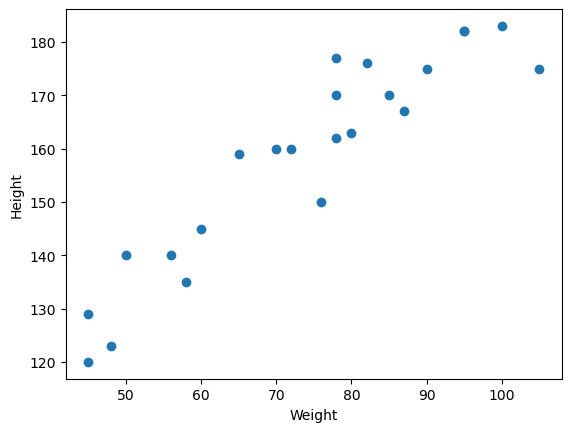

In [33]:
#check the relationship is linear or not

plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()


### this shows linear relationship

In [36]:
#check the correlation
df.corr() # shows positive correlation

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


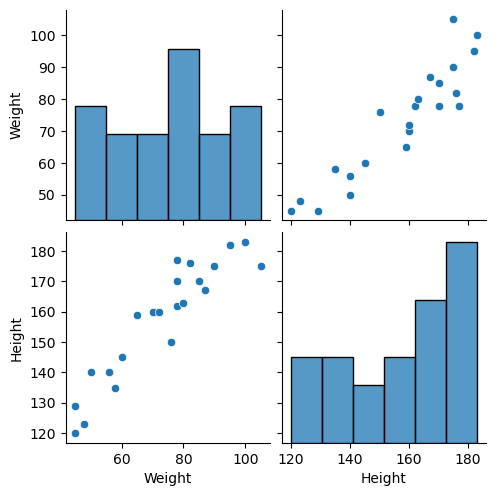

In [38]:
#pairplot
sns.pairplot(df)
plt.show()

In [70]:
#inpendent and independent features
X = df[['Weight']] #independent features must be in data frame or 2d array
Y = df['Height']  # it can be in series or 1d array

In [72]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [74]:
y_train

12    175
1     135
13    183
5     162
2     123
11    182
20    129
3     145
4     160
18    150
16    140
21    140
22    160
7     175
10    176
14    170
19    167
6     163
Name: Height, dtype: int64

In [76]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

In [78]:
#standardization
from sklearn.preprocessing import StandardScaler

In [80]:
scaler = StandardScaler()

In [82]:
X_train = scaler.fit_transform(X_train)

In [84]:
X_test = scaler.transform(X_test) # use tranform only to use onlye X_train mean and std in order to avoid data leakage

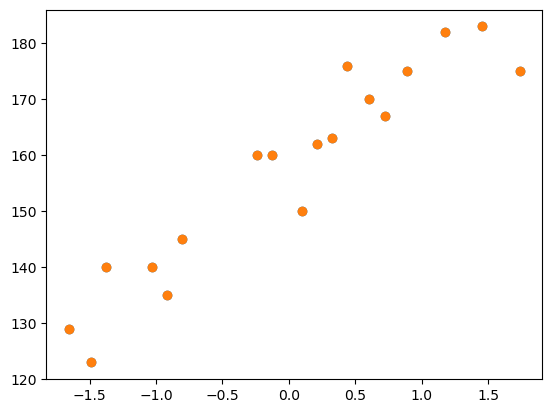

In [90]:
plt.scatter(X_train, y_train)
plt.show()

In [92]:
# apply linear regression
from sklearn.linear_model import LinearRegression


In [123]:
regressor = LinearRegression()

In [125]:
regressor.fit(X_train,y_train)

LinearRegression()

In [127]:
print("Cofficient:" ,regressor.coef_)
print("Intercept:" , regressor.intercept_)

Cofficient: [17.03440872]
Intercept: 157.5


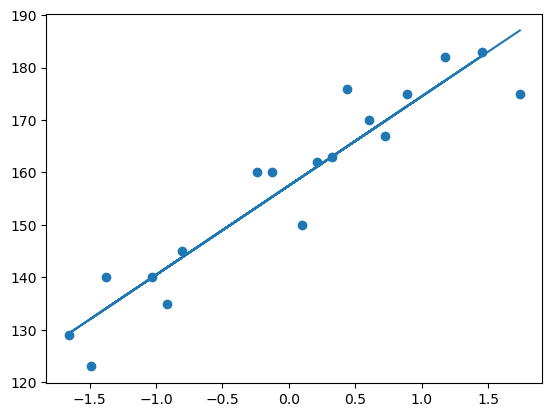

In [129]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),)
plt.show()

## Prediction on test data

1. Predicted height output  = intercept + coef_(Weights)
2. y_pred = 157.5 + 17.03 (X-test)

In [137]:
y_pred_test = regressor.predict(X_test)

In [139]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

In [141]:
y_pred_test

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

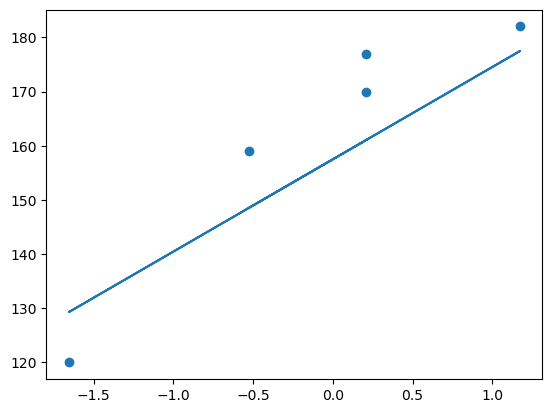

In [147]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred_test)
plt.show()

## Performance metrics

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [162]:
mse = mean_squared_error(y_test,y_pred_test)
mae =  mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print('MSE: ', mse)
print('MAE: ', mae)
print('RMSE: ', rmse)

MSE:  109.77592599051654
MAE:  9.822657814519227
RMSE:  10.477400726827076


In [166]:
score =  r2_score(y_test, y_pred_test)

###  R^2 Score

R^2 = 1- SSR/SST

where SSR is sum of residuals
SST is sum of totals

In [164]:
from sklearn.metrics import r2_score

In [168]:
score

0.7769869860423441

### Adjusted R squared

1-(1-R^2)(n-1)/(n-k-1)



where n  is number of observations and k is the number pf predictor variables

In [184]:
1- (1-score)*(len(y_test) -1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

## Using OLS(Ordinary least square)

In [191]:
import statsmodels.api as sm

In [197]:
model = sm.OLS(y_train,X_train).fit()
predictions = model.predict(X_test)

In [221]:
print(model.summary2())

                       Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): -0.047  
Dependent Variable:     Height           AIC:                         235.2463
Date:                   2025-03-13 12:40 BIC:                         236.1367
No. Observations:       18               Log-Likelihood:              -116.62 
Df Model:               1                F-statistic:                 0.1986  
Df Residuals:           17               Prob (F-statistic):          0.661   
R-squared (uncentered): 0.012            Scale:                       26302.  
-----------------------------------------------------------------------------------
            Coef.       Std.Err.        t         P>|t|        [0.025        0.975]
-----------------------------------------------------------------------------------
x1         17.0344       38.2261      0.4456      0.6615      -63.6156      97.6844
--------------------------------------------------------

##### Prediction using new data

In [225]:
regressor.predict(scaler.transform([[89]]))

array([171.67817577])